# Kalman Filter Robot Localization in a Simulated Maze (with Heatmaps)

_Generated: 2025-10-22T17:00:39.895203Z_

**Objective.** Fuse a **noisy GPS** (position) with **odometry velocity** in a linear-Gaussian state-space model to localize a robot in a 2D maze. We implement a **Kalman filter from first principles** and visualize the evolving **positional belief** as heat maps over the maze.

**Model.** State $x_t=[p_x,p_y,v_x,v_y]^\top$. With time step $\Delta t$,
$$x_t = F x_{t-1} + w_t,\quad w_t\sim\mathcal{N}(0,Q).$$
where $F=\begin{bmatrix}1&0&\Delta t&0\\0&1&0&\Delta t\\0&0&1&0\\0&0&0&1\end{bmatrix}$. Measurement combines GPS and odometry:
$$z_t=\begin{bmatrix}p_x\\p_y\\v_x\\v_y\end{bmatrix} + v_t,\quad v_t\sim\mathcal{N}(0,R).$$
Walls are used **only for visualization**; the filter remains continuous.

## 0. Environment & Dependencies

In [1]:
import sys, platform, subprocess
def _sh(cmd):
    try:
        out = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT, text=True)
    except Exception as e:
        out = f"[command failed] {e}"
    print(out)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("In Colab:", "google.colab" in sys.modules)
print("\nNVIDIA SMI (if present):")
_sh("nvidia-smi || true")

!pip -q install --upgrade pip
!pip -q install numpy matplotlib

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
In Colab: True

NVIDIA SMI (if present):
/bin/sh: 1: nvidia-smi: not found

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.4 MB/s eta 0:00:00


## 1. Imports, Seeding, and Helpers

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

np.set_printoptions(precision=4, suppress=True)
SEED = 42
rng = np.random.default_rng(SEED)

def plot_cov_ellipse(mu, Sigma, nstd=2.0, ax=None, **kwargs):
    # Draw covariance ellipse for 2D Gaussian (positional block).
    import numpy as np
    from matplotlib.patches import Ellipse
    if ax is None:
        ax = plt.gca()
    vals, vecs = np.linalg.eigh(Sigma)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    width, height = 2 * nstd * np.sqrt(vals)
    e = Ellipse(xy=mu, width=width, height=height, angle=theta, fill=False, **kwargs)
    ax.add_patch(e)
    return e

## 2. Maze Definition (for Visualization Mask)

We define a small occupancy grid (1=wall, 0=free). The Kalman filter runs in continuous $(x,y)$; we rasterize the positional Gaussian onto this grid, setting walls to zero to obtain a heat map.

In [3]:
@dataclass
class Maze:
    grid: np.ndarray  # 0=free, 1=wall
    scale: float      # meters per cell

def make_maze():
    grid = np.array([
        [0,0,0,0,0,0,0,0,0,0],
        [0,1,1,0,1,1,0,1,1,0],
        [0,0,0,0,0,0,0,0,0,0],
        [0,1,0,1,0,1,0,1,0,1],
        [0,0,0,0,0,0,0,0,0,0],
        [0,1,1,0,1,1,0,1,1,0],
        [0,0,0,0,0,0,0,0,0,0]
    ], dtype=int)
    scale = 1.0  # 1 meter per cell
    return Maze(grid=grid, scale=scale)

maze = make_maze()
H, W = maze.grid.shape
free_mask = (maze.grid == 0)
print("Maze size:", H, "x", W, "| free cells:", free_mask.sum())

Maze size: 7 x 10 | free cells: 53


## 3. Linear-Gaussian Model

We use a constant-velocity model. Measurements stack GPS position and odometry velocity.

In [4]:
def build_models(dt=0.5, sigma_acc=0.5, sigma_gps=0.7, sigma_odo=0.2):
    F = np.array([[1,0,dt,0],
                  [0,1,0,dt],
                  [0,0,1,0],
                  [0,0,0,1]], dtype=float)
    # Process noise from white acceleration (continuous white noise approx)
    q = sigma_acc**2
    Q = np.array([[dt**4/4, 0,        dt**3/2, 0       ],
                  [0,        dt**4/4, 0,        dt**3/2],
                  [dt**3/2,  0,        dt**2,   0       ],
                  [0,        dt**3/2,  0,        dt**2  ]], dtype=float) * q
    # Measurements: [px, py, vx, vy]
    H = np.eye(4)
    R = np.diag([sigma_gps**2, sigma_gps**2, sigma_odo**2, sigma_odo**2])
    return F, Q, H, R

F, Q, H, R = build_models()

## 4. Simulate Trajectory and Sensors

We simulate a feasible path through free space and generate noisy GPS (position) and odometry (velocity).

In [6]:
def simulate_path(T=30, dt=0.5):
    # Create a path that snakes through corridors
    px, py = 1.0, 1.0
    vx, vy = 0.0, 0.0
    traj = []
    cmds = []
    # Piecewise-constant velocity segments (m/s)
    segments = [
        (6, (1.0, 0.0)),  # right
        (4, (0.0, 1.0)),  # up
        (6, (1.0, 0.0)),  # right
        (4, (0.0,-1.0)),  # down
        (6, (1.0, 0.0)),  # right
        (4, (0.0, 1.0)),  # up
    ]
    for nsteps, v in segments:
        for _ in range(nsteps):
            vx, vy = v
            px += vx*dt; py += vy*dt
            traj.append([px, py, vx, vy])
            cmds.append(v)
            if len(traj) >= T: break
        if len(traj) >= T: break
    traj = np.array(traj, dtype=float)
    cmds = np.array(cmds, dtype=float)
    return traj, cmds

dt = 0.5
T = 30
true_traj, odo_cmds = simulate_path(T=T, dt=dt)

# Sensors: GPS and odometry (noisy)
sigma_gps = 0.7
sigma_odo = 0.2
gps = true_traj[:, :2] + rng.normal(0, sigma_gps, size=(T,2))
odo = true_traj[:, 2:] + rng.normal(0, sigma_odo, size=(T,2))

# Assemble measurement vector z_t = [px, py, vx, vy]
zs = np.hstack([gps, odo])

## 5. Kalman Filter (From Scratch)

Standard predict–update recursion with symmetric covariance maintenance.

In [7]:
def kalman_filter(F, Q, H, R, zs, x0, P0):
    T = zs.shape[0]
    xs = np.zeros((T, x0.shape[0]))
    Ps = np.zeros((T, x0.shape[0], x0.shape[0]))
    x = x0.copy(); P = P0.copy()
    I = np.eye(P.shape[0])
    for t in range(T):
        # Predict
        x = F @ x
        P = F @ P @ F.T + Q
        # Update
        z = zs[t]
        y = z - H @ x
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)
        x = x + K @ y
        P = (I - K @ H) @ P
        # Symmetrize for numerical stability
        P = 0.5*(P + P.T)
        xs[t] = x; Ps[t] = P
    return xs, Ps

F, Q, H, R = build_models(dt=dt, sigma_acc=0.5, sigma_gps=sigma_gps, sigma_odo=sigma_odo)

# Prior
x0 = np.array([1.0, 1.0, 0.0, 0.0], dtype=float)
P0 = np.diag([2.0, 2.0, 1.0, 1.0])

xs, Ps = kalman_filter(F, Q, H, R, zs, x0, P0)
print("KF finished. Shapes:", xs.shape, Ps.shape)

KF finished. Shapes: (30, 4) (30, 4, 4)


## 6. Heatmap Rendering of Positional Belief

At each step, we rasterize the 2D marginal $\mathcal{N}(\mu_{pos}, \Sigma_{pos})$ onto the maze grid as a likelihood heat map (walls forced to zero).

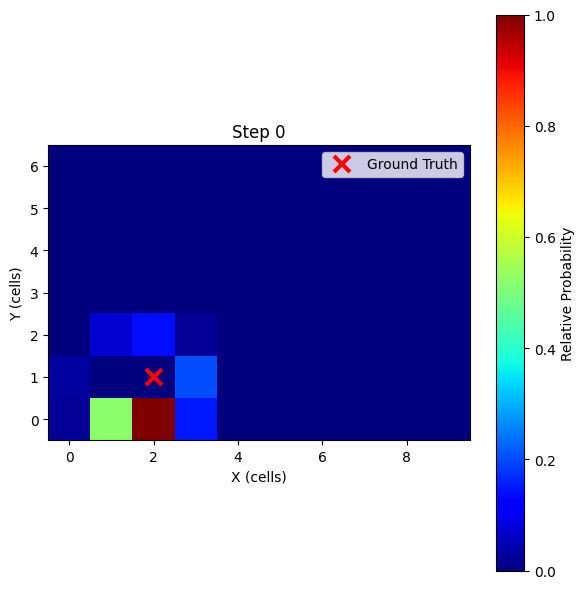

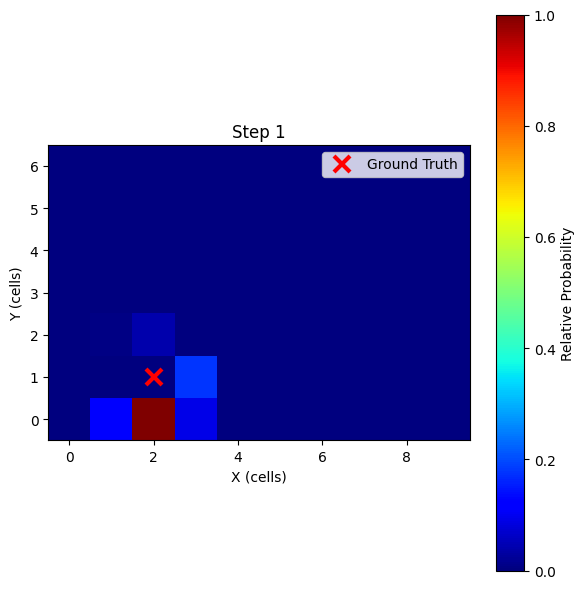

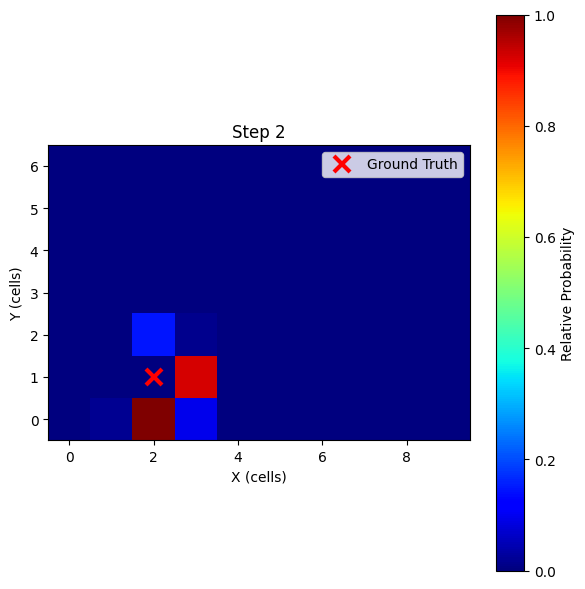

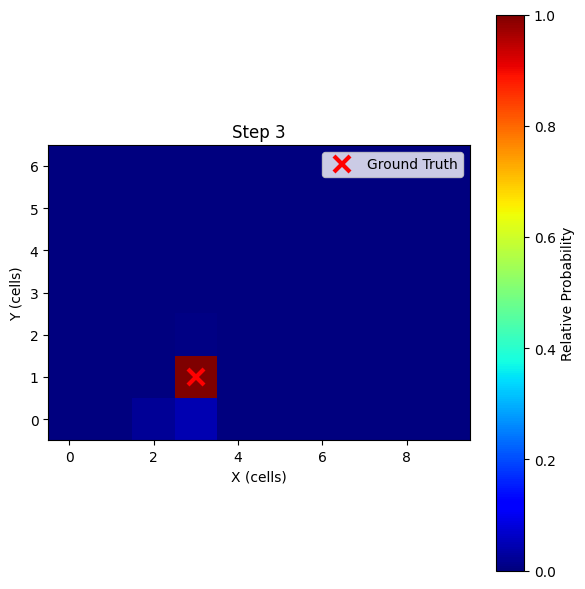

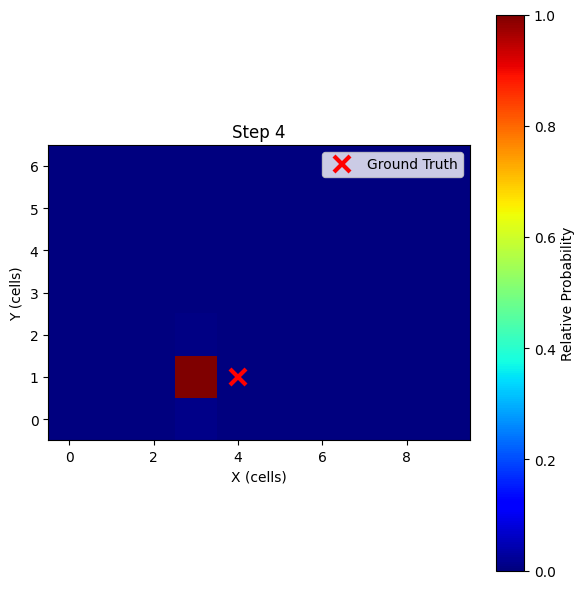

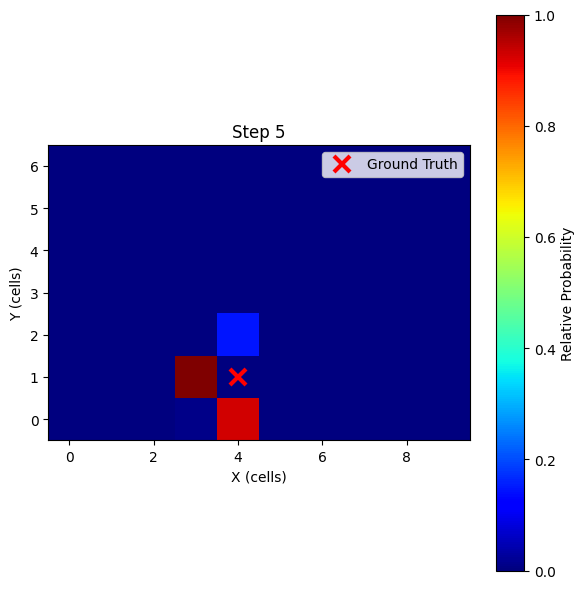

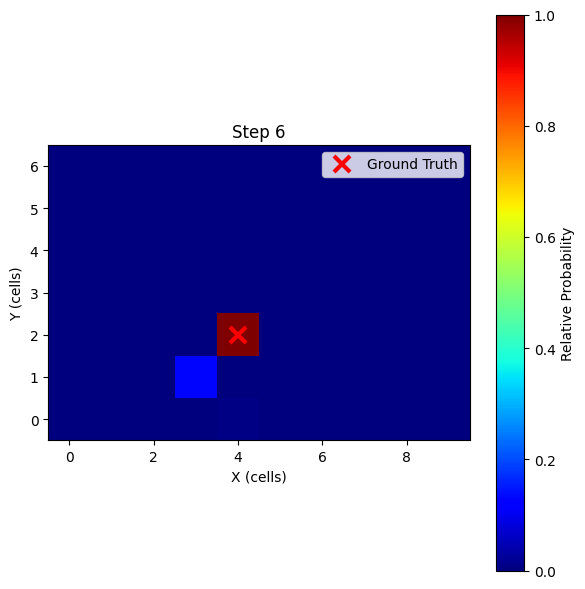

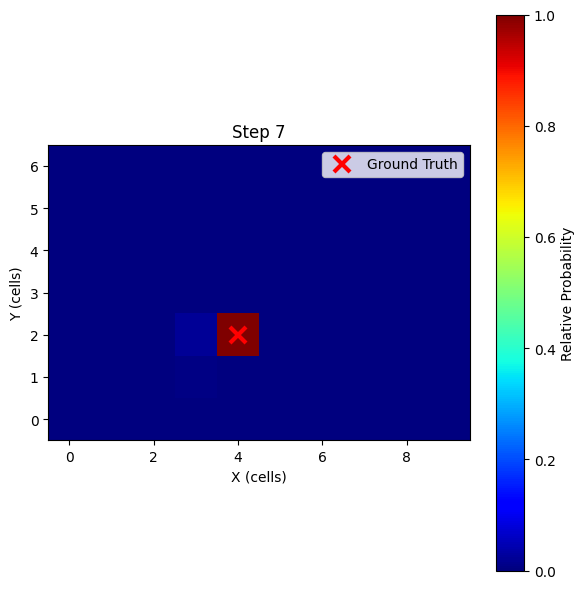

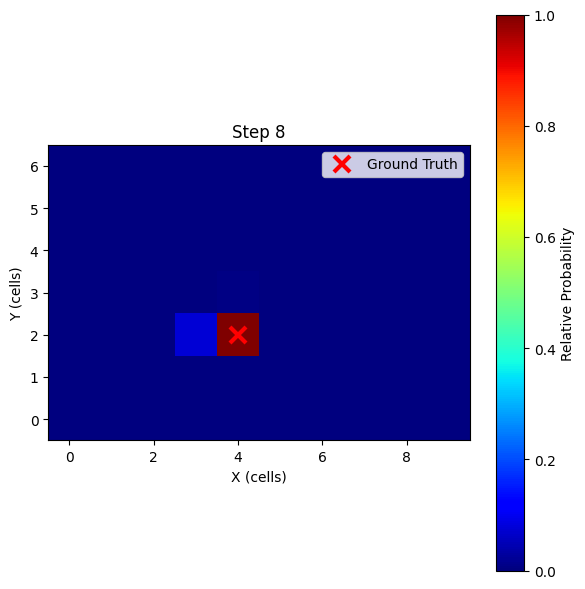

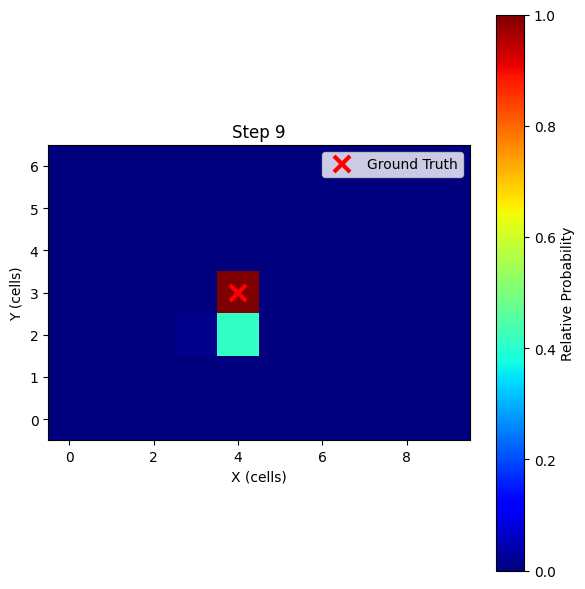

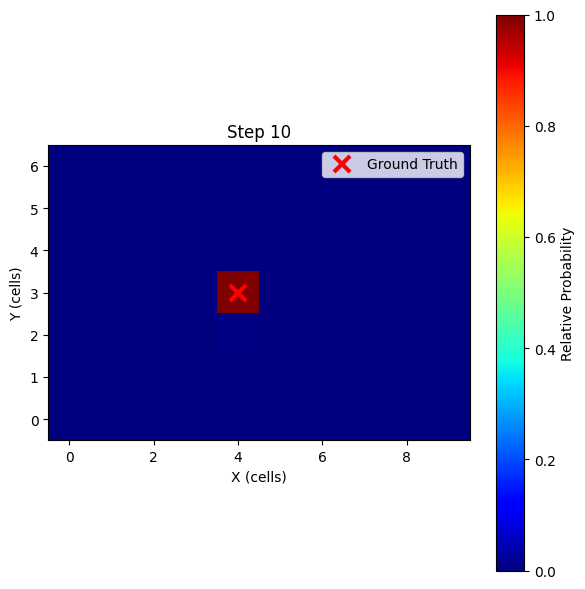

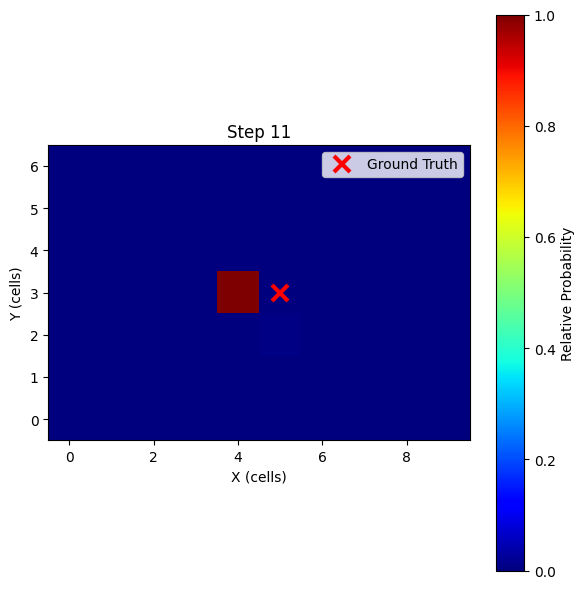

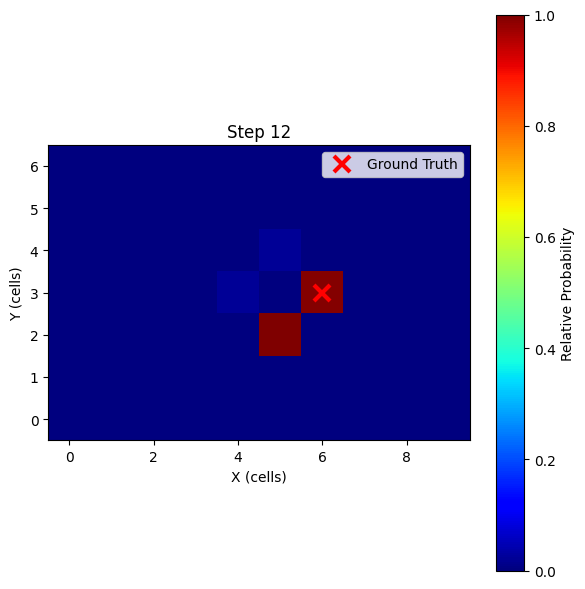

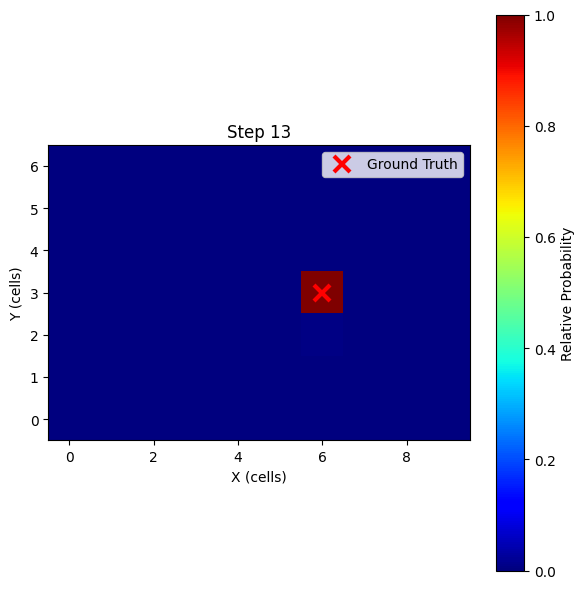

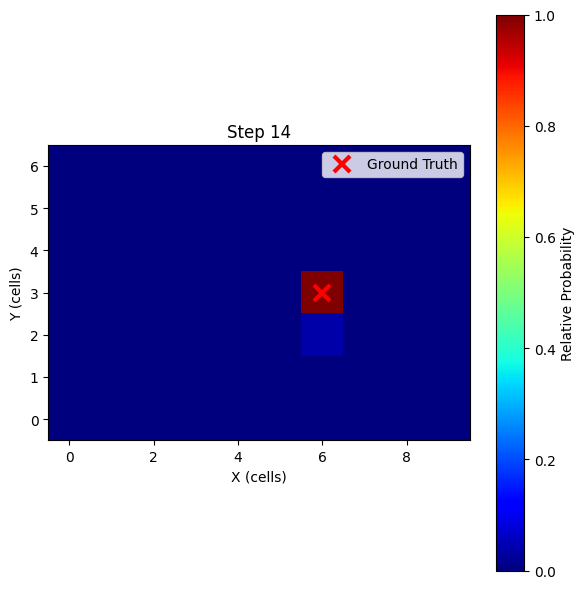

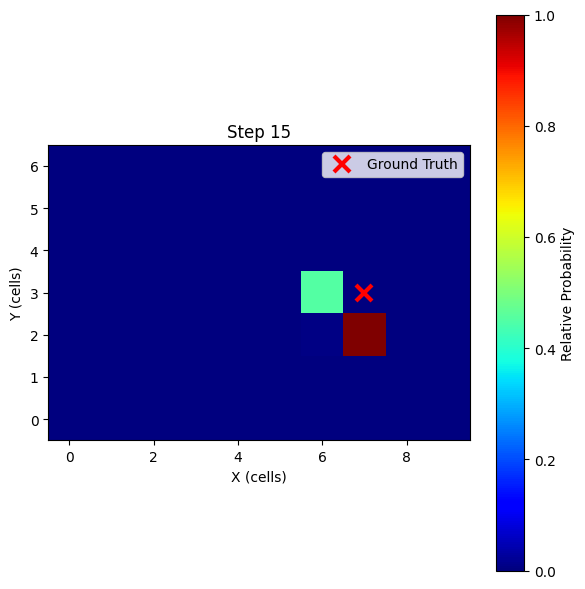

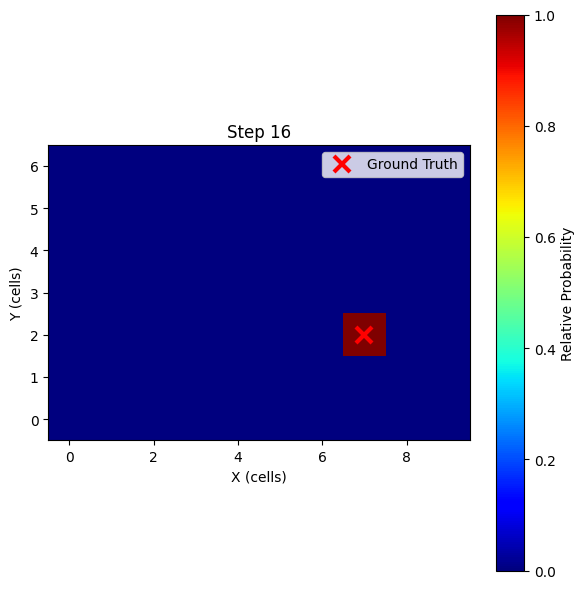

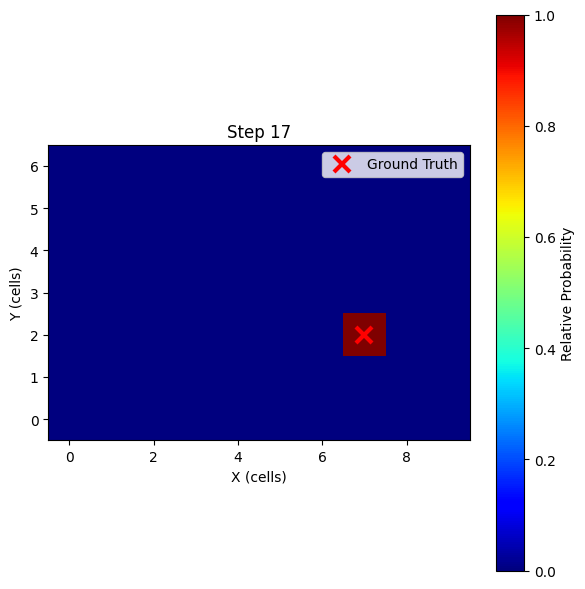

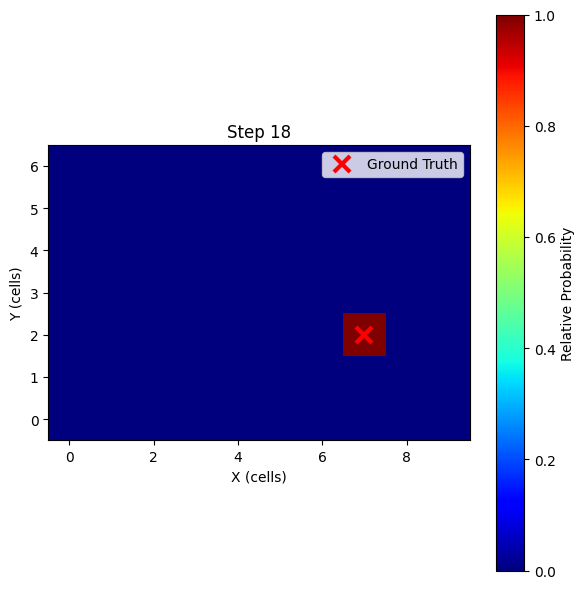

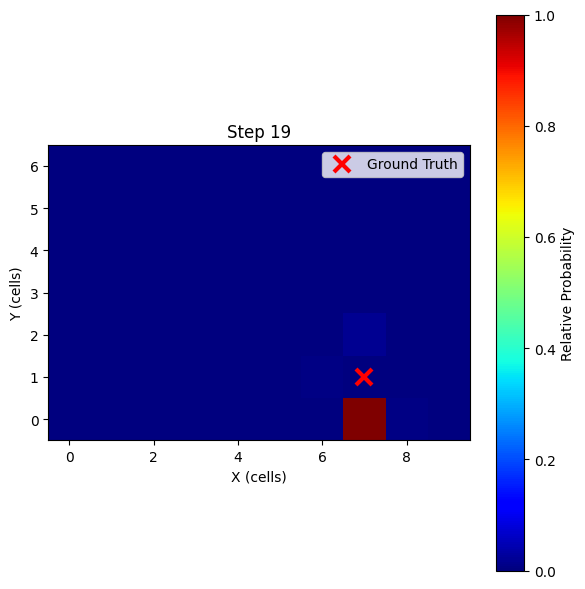

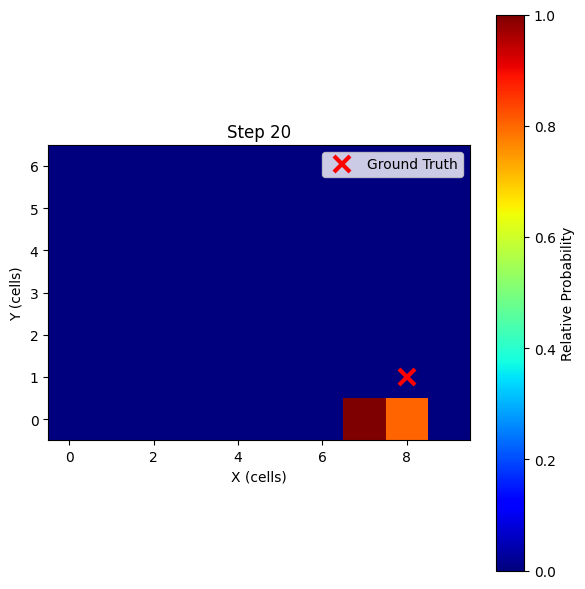

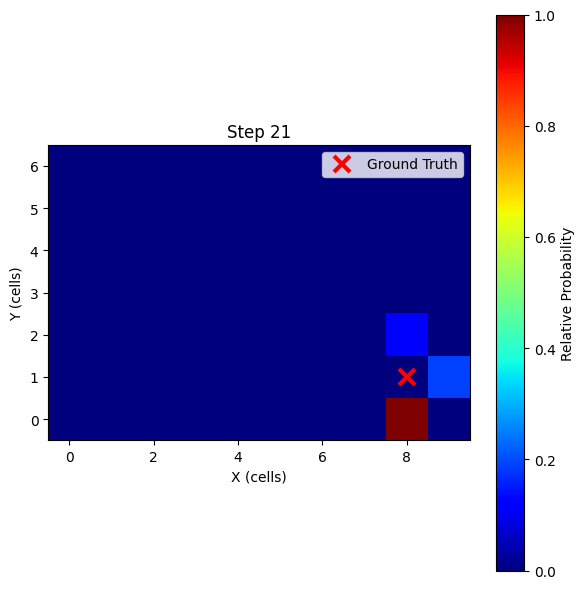

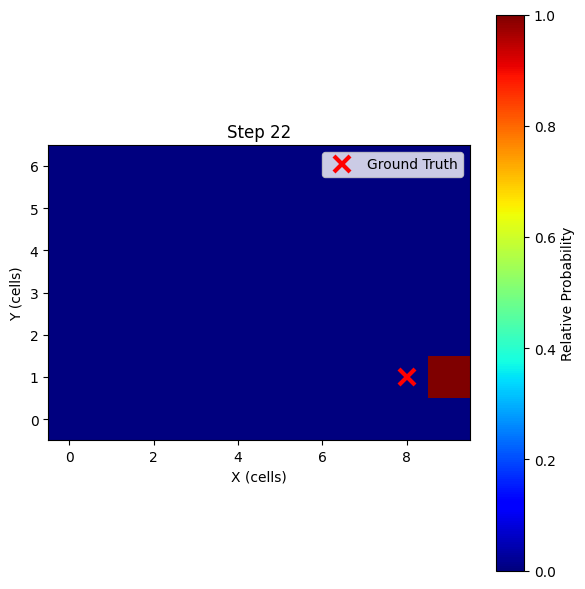

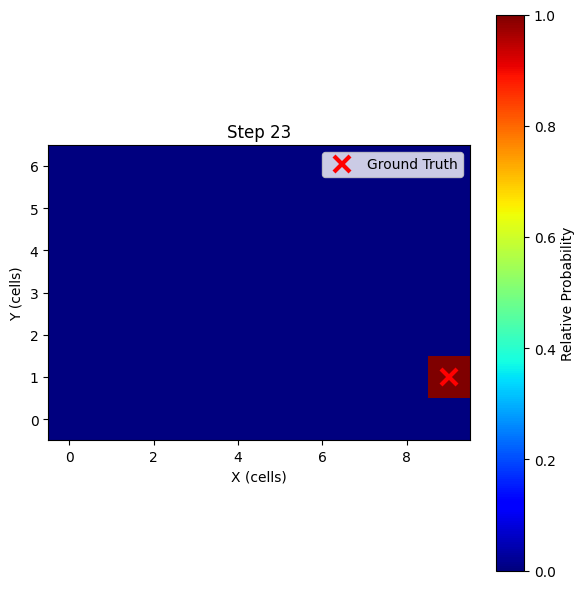

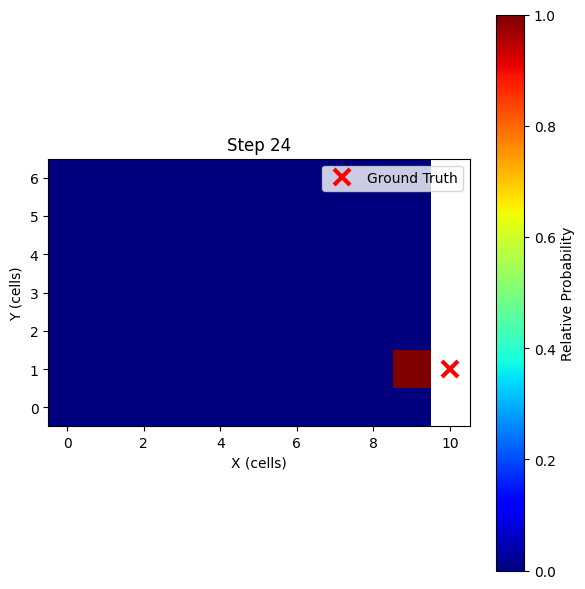

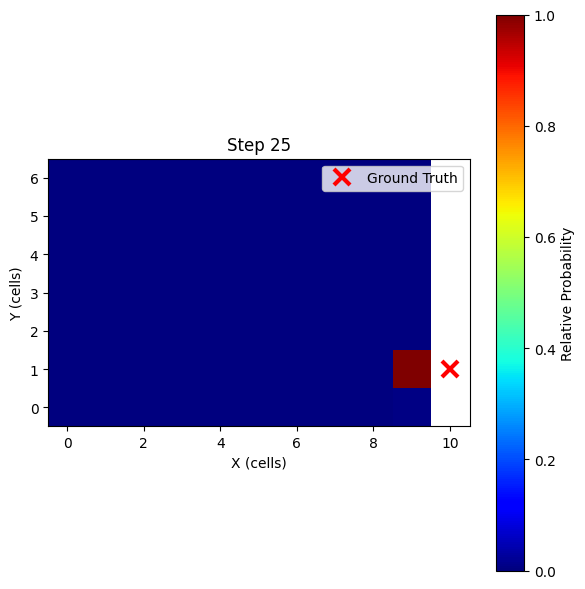

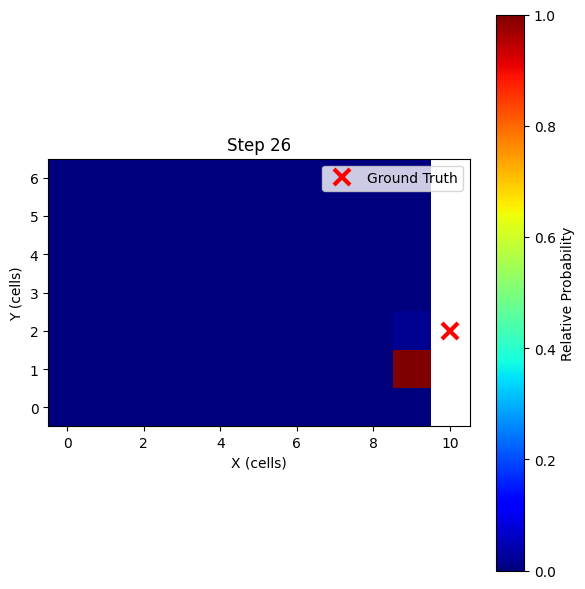

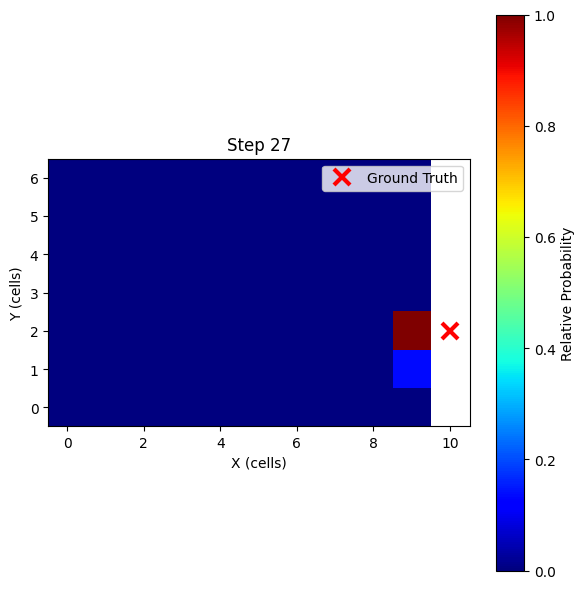

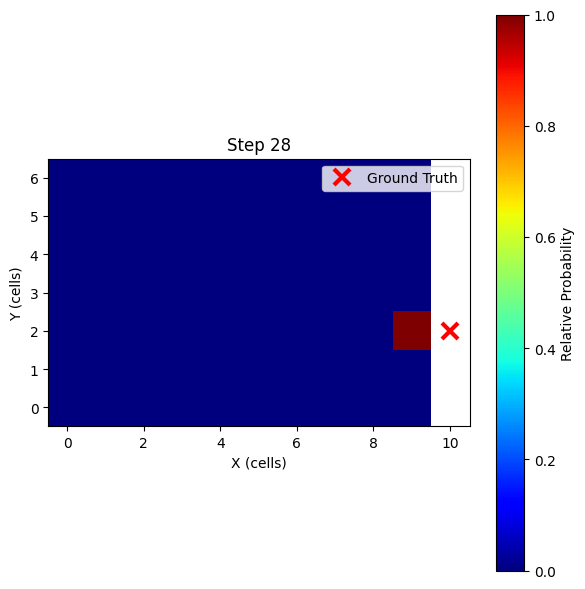

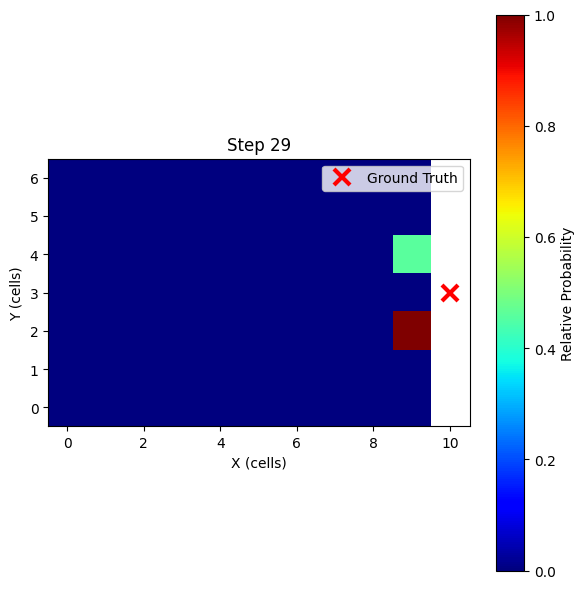

In [15]:
def _as_int_scalar(x, name):
    """Coerce x to a Python int if it is a scalar (Python, 0-D NumPy, or size-1 array)."""
    xa = np.asarray(x)
    if xa.ndim == 0:
        return int(xa)
    if xa.size == 1:
        return int(xa.ravel()[0])
    raise ValueError(f"{name} must be a scalar; got array with shape {xa.shape}.")

def gaussian_pdf_grid(mu, Sigma, H, W, scale=1.0, wall_mask=None, normalize=True, eps=1e-12):
    """
    Build a (H, W) heat map of a 2D Gaussian with mean mu (x,y) and covariance Sigma (2x2).
    - scale: multiplies grid coordinates before comparison (useful if your state is in world units).
    - wall_mask: boolean mask with shape (H, W); locations set True will be set to 0.
    - normalize: if True, divide by max so output is in [0,1].
    """
    # --- Coerce sizes to plain ints (fixes your TypeError) ---
    H = _as_int_scalar(H, "H")
    W = _as_int_scalar(W, "W")

    # --- Coerce and sanitize parameters ---
    mu = np.asarray(mu, dtype=float).reshape(2)
    Sigma = np.asarray(Sigma, dtype=float).reshape(2, 2)

    # Symmetrize and floor eigenvalues for numerical stability
    Sigma = 0.5 * (Sigma + Sigma.T)
    w, V = np.linalg.eigh(Sigma)
    w = np.clip(w, eps, None)
    Sigma = (V * w) @ V.T

    det = float(np.linalg.det(Sigma))
    if not np.isfinite(det) or det <= 0.0:
        det = max(det, eps)

    Sigma_inv = np.linalg.inv(Sigma)

    # --- Vectorized grid of coordinates (ij = row->y, col->x) ---
    ys, xs = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
    coords = np.stack([xs, ys], axis=-1).astype(float)

    # If your (x,y) state is in world units and each cell corresponds to `scale` units,
    # compare in the same units by scaling grid coordinates:
    if scale is None:
        scale = 1.0
    coords *= float(scale)

    # --- Quadratic form for Gaussian exponent ---
    diff = coords - mu  # shape (H, W, 2)
    quad = (diff @ Sigma_inv * diff).sum(axis=-1)  # shape (H, W)

    # --- Unnormalized PDF ---
    pdf = np.exp(-0.5 * quad) / (2.0 * np.pi * np.sqrt(det))

    # --- Apply walls if provided ---
    if wall_mask is not None:
        # Ensure mask has the right shape
        mask = np.asarray(wall_mask, dtype=bool)
        if mask.shape != (H, W):
            raise ValueError(f"wall_mask must have shape {(H, W)}, got {mask.shape}.")
        pdf = np.where(mask, 0.0, pdf)

    # --- Optional normalization for visualization ---
    if normalize:
        m = np.nanmax(pdf)
        if np.isfinite(m) and m > 0:
            pdf = pdf / m

    return pdf

import matplotlib.pyplot as plt

def show_heatmap(grid_img, true_pos, maze, title=None):
    """
    Displays the given heatmap and marks the ground truth position with a red 'X'.

    Parameters
    ----------
    grid_img : np.ndarray
        The heatmap image (2D array of probability values).
    true_pos : array-like
        Ground truth position [x, y] in world units (same as in true_traj).
    maze : object
        Maze object containing .scale (world-to-grid scale factor).
    title : str, optional
        Title for the plot.
    """
    plt.figure(figsize=(6,6))
    plt.imshow(grid_img, cmap='jet', origin='lower')
    if title:
        plt.title(title)

    # Compute grid coordinates from world position
    x_true = int(round(true_pos[0] / maze.scale))
    y_true = int(round(true_pos[1] / maze.scale))

    # Draw a red X at the ground truth cell
    plt.plot(x_true, y_true, 'rx', markersize=12, mew=3, label='Ground Truth')

    plt.legend(loc='upper right')
    plt.xlabel('X (cells)')
    plt.ylabel('Y (cells)')
    plt.colorbar(label='Relative Probability')
    plt.tight_layout()
    plt.show()

wall_mask = (maze.grid == 1)
height, width = wall_mask.shape  # ints

heatmaps = []
for t in range(T):
    mu_pos = xs[t, :2]
    Sigma_pos = Ps[t, :2, :2]
    grid_img = gaussian_pdf_grid(mu_pos, Sigma_pos, height, width, float(maze.scale), wall_mask)
    # zero out walls explicitly (already zero), for clarity
    grid_img[wall_mask] = 0.0
    heatmaps.append(grid_img)
    show_heatmap(grid_img, true_traj[t, :2], maze, title=f"Step {t}")

## 7. Trajectories and Covariance Ellipses

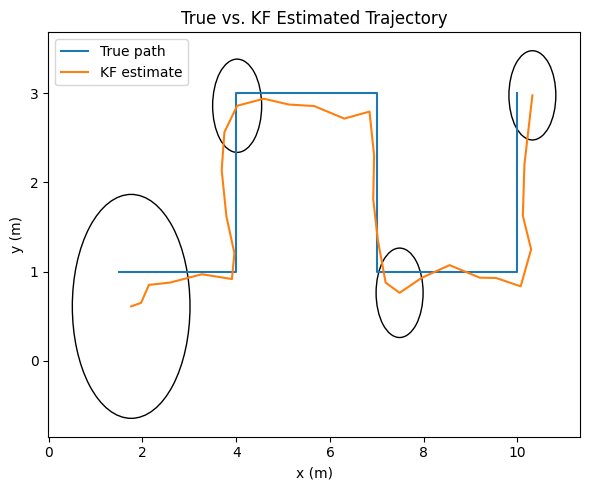

In [11]:
true_xy = true_traj[:, :2]
est_xy = xs[:, :2]

fig = plt.figure(figsize=(6,5))
plt.plot(true_xy[:,0], true_xy[:,1], label="True path")
plt.plot(est_xy[:,0], est_xy[:,1], label="KF estimate")
# Draw a few covariance ellipses
for t in [0, len(Ps)//3, 2*len(Ps)//3, len(Ps)-1]:
    plot_cov_ellipse(est_xy[t], Ps[t,:2,:2], nstd=2.0, ax=plt.gca())
plt.title("True vs. KF Estimated Trajectory")
plt.xlabel("x (m)"); plt.ylabel("y (m)"); plt.legend()
plt.tight_layout(); plt.show()

## 8. Save Artifacts & Download

We persist the maze, measurements, KF outputs, and a few heatmap PNGs. Use the helper below to download a ZIP in Colab.

In [12]:
import os
os.makedirs("artifacts", exist_ok=True)

np.savez("artifacts/kf_localization_run.npz",
         maze_grid=maze.grid, maze_scale=np.array([maze.scale]),
         dt=np.array([dt]),
         true_traj=true_traj, gps=gps, odo=odo, zs=zs,
         xs=xs, Ps=Ps)

# Save sample heatmaps
def save_heat(img, fname, title):
    fig = plt.figure(figsize=(4.5,4.5))
    plt.imshow(img, interpolation='nearest')
    plt.title(title); plt.axis('off'); plt.tight_layout()
    fig.savefig(f"artifacts/{fname}", dpi=120); plt.close(fig)

save_heat(heatmaps[0], "belief_t0.png", "Belief t=0")
mid = len(heatmaps)//2
save_heat(heatmaps[mid], f"belief_t{mid}.png", f"Belief t={mid}")
save_heat(heatmaps[-1], "belief_tT.png", "Belief t=T")

print("Saved artifacts:", os.listdir("artifacts"))

Saved artifacts: ['belief_tT.png', 'kf_localization_run.npz', 'belief_t0.png', 'belief_t15.png']


In [13]:
# Colab download helper
import shutil
from pathlib import Path
try:
    from google.colab import files  # type: ignore
    if Path('artifacts').exists():
        shutil.make_archive('artifacts', 'zip', 'artifacts')
        files.download('artifacts.zip')
    else:
        print('No artifacts folder found.')
except Exception as e:
    print('Colab download helper not available in this environment:', e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Extensions & Exercises

- Add an IMU (accelerometer/gyro) as additional measurements; compare with/without odometry.
- Enforce map constraints softly by downweighting mass in walls (pseudo-measurement) or use an **EKF** with nonlinear map penalty.
- Vary sensor noise (R) and process noise (Q) to study filter consistency and NEES.
- Extend to **EKF SLAM** by augmenting landmarks; or compare with a **particle filter** for non-Gaussian posteriors.